# 6. Modelado con scikit-learn

Sección 9.10.4.4 del enunciado. Se ajustan los seis modelos con `GridSearchCV` (sin `Pipeline`),
tres pliegues estratificados, `scoring="roc_auc"` y `n_jobs=-1`, sobre la matriz de 1.078.447 x 72
del capítulo 5. Para cada modelo se registran el tiempo de entrenamiento con validación cruzada
(incluido el reajuste final con todo el entrenamiento), el tiempo de predicción sobre las 269.612
observaciones de prueba y las métricas, y se guardan las puntuaciones continuas de prueba con
`id` y `default` para las pruebas del capítulo 8.

**Umbral de decisión.** Las métricas que dependen de un umbral (accuracy, precisión, recall, F1,
matriz de confusión) se calculan en el umbral que maximiza el índice de Youden
($J = TPR - FPR$) **en el conjunto de entrenamiento**, nunca en el de prueba. Con 20 % de
defaults, el umbral de 0,5 deja casi todos los préstamos como "pagados" (sección 6.9). Como
referencia también se reportan las métricas en el umbral por defecto (0,5 para probabilidades y
0 para la función de decisión de `LinearSVC`).

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, "../src")
os.environ["PYTHONPATH"] = os.path.abspath("../src") + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import features as fe
import modelado as mo
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 180)
print("scikit-learn", sklearn.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print("Equipo:")
for k, v in u.hardware().items():
    print(f"  {k}: {v}")

scikit-learn 1.9.1 | numpy 2.4.6 | pandas 2.3.3
Equipo:
  sistema: Darwin 27.0.0
  python: 3.11.16
  nucleos_logicos: 10
  cpu: Apple M5
  nucleos_rendimiento: 4
  nucleos_eficiencia: 6
  ram_gb: 24.0


**Hardware.** Todos los tiempos de este capítulo y del siguiente se midieron en el mismo equipo:
un portátil Apple M5 con 10 núcleos (4 de rendimiento y 6 de eficiencia) y 24 GB de memoria
unificada, sin otros procesos pesados en ejecución. scikit-learn paraleliza la búsqueda con
`joblib` (`n_jobs=-1`: hasta 10 ajustes simultáneos).

## 6.1 Preprocesamiento

Para que el tiempo sea comparable con el de PySpark (capítulo 7), el preprocesamiento se mide
desde el mismo punto de partida: el CSV comprimido. pandas lee solo las columnas necesarias,
filtra los préstamos cerrados, construye las variables, las une con la partición común y ajusta
el `ColumnTransformer` con entrenamiento. Se comprueba que el resultado es idéntico a la base de
modelado guardada en el capítulo 5.

In [2]:
print("Modo de prueba de humo activo:", bool(u.FRACCION_PRUEBA))
t0 = time.time()
base_csv = fe.base_pandas_desde_csv()
d = fe.preparar_sklearn(base_csv)
t_preproc = time.time() - t0
n = len(d["y_train"])
print(f"Preprocesamiento desde el CSV: {t_preproc:.1f} s | X_train {d['X_train'].shape} | X_test {d['X_test'].shape}")
igual = base_csv.sort_values("id").reset_index(drop=True).equals(
    pd.read_parquet(u.MODELO).sort_values("id").reset_index(drop=True))
print("¿Idéntica a la base de modelado del capítulo 5?", igual)
del base_csv
u.guardar_json({"t_preprocesamiento_s": t_preproc, "n_train": n, "n_test": len(d["y_test"])},
               u.RESULTADOS / "sklearn_preprocesamiento.json")

Modo de prueba de humo activo: False


Preprocesamiento desde el CSV: 17.6 s | X_train (1078447, 72) | X_test (269612, 72)


¿Idéntica a la base de modelado del capítulo 5? True


## 6.2 Espacios de búsqueda y equivalencia con PySpark

| Modelo | Configuración fija | Espacio de búsqueda |
|---|---|---|
| `LogisticRegression` | L2, `lbfgs`, `max_iter=1000` | $C = 1/(\lambda n)$, $\lambda \in \{10^{-6}, 10^{-5}, 10^{-4}\}$ |
| `DecisionTreeClassifier` | Gini, cortes exactos | `max_depth` ∈ {5, 10, 15} |
| `RandomForestClassifier` | `max_features="sqrt"`, bootstrap | `n_estimators` ∈ {10, 50, 100} × `max_depth` ∈ {5, 10, 15} |
| `GradientBoostingClassifier` | `learning_rate=0.1`, pérdida logística | `n_estimators` ∈ {50, 100} × `max_depth` ∈ {3, 5} |
| `LinearSVC` | `loss="hinge"`, L2, dual | $C = 1/(\lambda n)$, mismo $\lambda$ |
| `GaussianNB` | por defecto | sin búsqueda (validación cruzada de la única configuración) |

Con $n$ = 1.078.447, $C \in \{0{,}927;\ 0{,}0927;\ 0{,}00927\}$. La relación se deriva de las
funciones objetivo:

$$\text{sklearn: } \tfrac12\lVert w\rVert^2 + C\sum_{i=1}^{n}\ell_i
\quad\Longleftrightarrow\quad
\text{Spark: } \tfrac1n\sum_{i=1}^{n}\ell_i + \tfrac{\lambda}{2}\lVert w\rVert^2 ,$$

porque dividir la primera entre $Cn$ da la segunda con $\lambda = 1/(Cn)$. En el reajuste final
con las $n$ filas de entrenamiento ambos problemas tienen el mismo óptimo si penalizan los mismos
coeficientes. En la práctica la equivalencia es aproximada por cuatro razones que se retoman en
el capítulo 12:

1. **Dentro de la validación cruzada** cada pliegue entrena con $m \approx 2n/3$ filas. Como $C$ se
   fijó con $n$, el $\lambda$ efectivo de scikit-learn en la búsqueda es $1/(Cm) = 1{,}5\lambda$,
   mientras que Spark aplica $\lambda$ sobre su pliegue. La selección compara, por tanto, puntos de
   la rejilla ligeramente distintos; con $\lambda \le 10^{-4}$ y un millón de filas la
   regularización es tan débil que el efecto es mínimo.
2. `liblinear` (usado por `LinearSVC`) penaliza también el intercepto; `lbfgs` y Spark no.
3. Los optimizadores y sus criterios de parada son distintos (`lbfgs` con hasta 1.000
   iteraciones y `liblinear` con hasta 5.000 en scikit-learn; L-BFGS/OWL-QN con 100 iteraciones en
   Spark). Se registra el número de iteraciones de cada modelo final para detectar si se alcanzó
   el límite.
4. En Spark se fija `standardization=False` para que la penalización actúe sobre las mismas
   variables ya escaladas; con el valor por defecto (`True`) Spark penaliza los coeficientes en una
   escala interna distinta, también los de las columnas one-hot.

**Pliegues.** `GridSearchCV` recibe `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)`
en lugar del entero `cv=3`: con un entero, scikit-learn toma los pliegues en el orden del archivo,
que sigue la fecha de emisión, y cada pliegue quedaría concentrado en unas pocas cohortes. Spark
asigna los pliegues al azar (con semilla), así que barajar en ambos entornos es lo comparable.
Los pliegues no son idénticos entre entornos (Spark los forma con un número aleatorio por fila y
no estratifica); con un millón de filas, los tres pliegues de cada entorno deberían tener tamaños
y tasas de default muy parecidos. La partición entrenamiento/prueba sí es la misma.

In [3]:
reg = mo.REG_PARAMS
grid_c = {"C": [1.0 / (lam * n) for lam in reg]}
print("Valores de C:", [f"{c:.5f}" for c in grid_c["C"]])
resultados = {}

Valores de C: ['0.92726', '0.09273', '0.00927']


## 6.3 Regresión logística

In [4]:
resultados["LogisticRegression"] = mo.ajustar_sklearn(
    "LogisticRegression",
    LogisticRegression(solver="lbfgs", max_iter=1000, random_state=u.SEMILLA),
    grid_c, d)
pd.read_csv(u.RESULTADOS / "sklearn" / "LogisticRegression_cv.csv")

,param_C,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,0.927259,0.716600,0.000179,5.346499,2
1,0.092726,0.716597,0.000179,4.934463,3
2,0.009273,0.716617,0.000169,5.450987,1


El AUC de validación es prácticamente el mismo para los tres valores de $C$ (0,71660 a 0,71662,
con desviaciones entre pliegues de 0,0002): con un millón de filas y 72 variables, la
penalización L2 en este rango es tan débil que apenas cambia los coeficientes. La búsqueda elige
$C = 0{,}00927$ ($\lambda = 10^{-4}$) por una diferencia en la quinta cifra decimal. `lbfgs`
converge en 35 iteraciones, muy lejos del límite de 1.000.

## 6.4 Árbol de decisión

In [5]:
resultados["DecisionTree"] = mo.ajustar_sklearn(
    "DecisionTree", DecisionTreeClassifier(random_state=u.SEMILLA), {"max_depth": [5, 10, 15]}, d)
pd.read_csv(u.RESULTADOS / "sklearn" / "DecisionTree_cv.csv")

,param_max_depth,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,5,0.695430,0.000690,6.992935,2
1,10,0.702394,0.000493,10.585217,1
2,15,0.667204,0.000918,12.742347,3


El árbol de profundidad 10 es el mejor (AUC 0,702). A profundidad 15 el AUC de validación cae a
0,667: con hojas cada vez más pequeñas el árbol memoriza el entrenamiento y sus probabilidades,
calculadas con pocas observaciones, ordenan peor los préstamos nuevos.

## 6.5 Bosque aleatorio

Durante la búsqueda cada bosque se entrena con un solo núcleo (`n_jobs=1` en el estimador) y
`GridSearchCV` reparte los 27 ajustes (9 combinaciones × 3 pliegues) entre los 10 núcleos. El
reajuste final con la mejor combinación (ajuste 28) y la predicción ya no compiten con otros
ajustes, así que se hacen aparte con `n_jobs=-1`, como en Spark, donde el reajuste usa los 10
hilos. `max_features="sqrt"` toma $\lfloor\sqrt{72}\rfloor = 8$ variables candidatas por nodo.

In [6]:
resultados["RandomForest"] = mo.ajustar_sklearn(
    "RandomForest",
    RandomForestClassifier(max_features="sqrt", bootstrap=True, random_state=u.SEMILLA, n_jobs=1),
    {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]}, d, n_jobs_reajuste=-1)
pd.read_csv(u.RESULTADOS / "sklearn" / "RandomForest_cv.csv")

,param_max_depth,param_n_estimators,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,5,10,0.703172,0.000827,8.845877,9
1,5,50,0.706889,0.000810,35.984995,8
2,5,100,0.707210,0.000789,71.249045,6
3,10,10,0.711047,0.000608,13.369107,5
4,10,50,0.714824,0.000673,61.675482,4
5,10,100,0.715496,0.000586,116.788032,3
6,15,10,0.707137,0.000629,16.163501,7
7,15,50,0.717635,0.000749,74.325954,2
8,15,100,0.719197,0.000572,106.482391,1


A diferencia del árbol individual, el bosque sí aprovecha la profundidad 15: promediar 100 árboles
decorrelacionados compensa la varianza de cada árbol profundo. El AUC crece con el número de
árboles en las tres profundidades, y con la profundidad cuando hay 50 o 100 árboles (con solo 10,
la profundidad 15 queda por debajo de la 10); la mejor combinación (100 árboles, profundidad 15, AUC 0,7192)
está en el borde de la rejilla: un bosque más grande o más profundo probablemente mejoraría un
poco, pero el enunciado fija el espacio de búsqueda.

## 6.6 Gradient boosting

Se usa `GradientBoostingClassifier` (árboles con cortes exactos), como pide el enunciado, y no
`HistGradientBoostingClassifier`: su costo con el conjunto completo es alto pero no prohibitivo
en este equipo (los tiempos se reportan abajo).

In [7]:
resultados["GradientBoosting"] = mo.ajustar_sklearn(
    "GradientBoosting",
    GradientBoostingClassifier(learning_rate=0.1, subsample=1.0, random_state=u.SEMILLA),
    {"n_estimators": [50, 100], "max_depth": [3, 5]}, d)
pd.read_csv(u.RESULTADOS / "sklearn" / "GradientBoosting_cv.csv")

,param_max_depth,param_n_estimators,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,3,50,0.714199,0.000334,247.950981,4
1,3,100,0.718902,0.000195,458.393913,3
2,5,50,0.719286,0.000179,400.177024,2
3,5,100,0.723086,0.000080,505.453506,1


El gradient boosting obtiene el mejor AUC de validación (0,7231 con 100 árboles de profundidad 5) y
también aquí el óptimo está en el borde de la rejilla. Es el modelo más costoso: cada árbol se
construye después del anterior, así que el reajuste final no puede paralelizarse y por sí solo
toma 401 s.

## 6.7 SVM lineal

`LinearSVC` usa por defecto la pérdida *squared hinge*; se fija `loss="hinge"` para igualar la
pérdida de Spark, lo que obliga a resolver el problema dual (`dual=True`) con `liblinear`. La
puntuación continua es la función de decisión $w^\top x + b$ (no hay probabilidades).

In [8]:
resultados["LinearSVC"] = mo.ajustar_sklearn(
    "LinearSVC",
    LinearSVC(loss="hinge", penalty="l2", dual=True, max_iter=5000, random_state=u.SEMILLA),
    grid_c, d, usa_decision=True)
pd.read_csv(u.RESULTADOS / "sklearn" / "LinearSVC_cv.csv")

,param_C,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,0.927259,0.504974,0.020865,598.826460,2
1,0.092726,0.451293,0.045066,116.676059,3
2,0.009273,0.505543,0.007425,18.468002,1


El SVM lineal con pérdida *hinge* no aprende un orden útil: su AUC de validación ronda 0,5 (entre
0,45 y 0,51 según $C$, con desviaciones de hasta 0,045 entre pliegues) y su umbral de Youden en
entrenamiento es −1,0000 (a cuatro decimales). El modelo final ($C$ = 0,00927) converge en 97
iteraciones, lejos del límite de 5.000, así que no es un fallo de convergencia: el capítulo 11
muestra que,
con estas clases tan solapadas y desbalanceadas, el óptimo de la pérdida *hinge* es casi la
solución trivial $w \approx 0$, $b = -1$ (todos los préstamos "pagados"): su función objetivo es
prácticamente la de esa solución, y la dirección de $w$, que determina el orden de las
puntuaciones, queda mal determinada. Los ajustes con $C = 0{,}927$ tardaron unos 600 s cada uno,
32 veces más que con $C = 0{,}00927$: con una penalización más débil el problema dual tarda mucho
más en converger cerca de esa solución degenerada.

## 6.8 Naive Bayes gaussiano

Sin hiperparámetros que buscar: `GridSearchCV` con una sola configuración ejecuta la misma
validación cruzada de tres pliegues (para tener el AUC de validación) y el reajuste final.

In [9]:
resultados["NaiveBayes"] = mo.ajustar_sklearn("NaiveBayes", GaussianNB(), {}, d)
pd.read_csv(u.RESULTADOS / "sklearn" / "NaiveBayes_cv.csv")

,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,0.652633,0.000828,0.838701,1


Naive Bayes gaussiano es el modelo más rápido (menos de 2 s con validación cruzada) pero el menos
preciso de los que aprenden (AUC 0,653): supone variables independientes dentro de cada clase y
con distribución normal, y aquí ninguna de las dos cosas se cumple (columnas one-hot binarias,
conteos con masa en cero y variables correlacionadas como `int_rate` y FICO).

## 6.9 Resumen de métricas

In [10]:
tabla = pd.DataFrame([mo.resumen(resultados[m]) for m in mo.ORDEN])
tabla.insert(0, "mejores parámetros", [str(resultados[m]["mejores_parametros"]) for m in mo.ORDEN])
tabla.round(4)

,mejores parámetros,AUC CV,AUC prueba,AUC-PR,Accuracy,Precision,Recall,F1,umbral,t_cv (s),t_pred (s)
LogisticRegression,{'C': 0.009272592904426457},0.7166,0.7171,0.3816,0.6478,0.3187,0.6704,0.4320,0.1926,8.5528,0.0247
DecisionTree,{'max_depth': 10},0.7024,0.7041,0.3615,0.6403,0.3110,0.6589,0.4226,0.2003,20.0037,0.0357
RandomForest,"{'max_depth': 15, 'n_estimators': 100}",0.7192,0.7197,0.3881,0.6856,0.3393,0.6059,0.4350,0.2232,215.2621,0.3948
GradientBoosting,"{'max_depth': 5, 'n_estimators': 100}",0.7231,0.7235,0.3948,0.6529,0.3233,0.6749,0.4372,0.1985,1104.8946,0.3399
LinearSVC,{'C': 0.009272592904426457},0.5055,0.5391,0.2228,0.5187,0.2181,0.5449,0.3115,-1.0000,616.1524,0.0236
NaiveBayes,{},0.6526,0.6525,0.2953,0.6199,0.2898,0.6220,0.3954,0.2115,1.9324,0.0893


* **Ordenamiento.** El gradient boosting (AUC 0,7235) y el bosque (0,7197) superan a la regresión
  logística (0,7171) por poco: las relaciones no lineales aportan, pero la mayor parte de la
  señal es aproximadamente lineal en las variables transformadas. El árbol individual (0,7041) y
  Naive Bayes (0,6525) quedan atrás, y el SVM *hinge* no discrimina (0,5391).
* **Sobreajuste.** En todos los modelos que aprenden, el AUC de prueba difiere del de validación
  cruzada en menos de 0,002: la validación cruzada estimó bien el desempeño fuera de muestra.
* **Umbral.** En los cuatro modelos con mejor AUC, los umbrales de Youden quedan entre 0,19 y
  0,22, cerca de la prevalencia de default (0,20). Con ellos se detecta entre 61 % y 67 % de los
  defaults con una precisión de 31 % a 34 % (F1 entre 0,42 y 0,44). Naive Bayes y el SVM quedan
  por debajo (F1 de 0,40 y 0,31).

In [11]:
defecto = pd.DataFrame({m: {k: resultados[m]["metricas_defecto"][k]
                            for k in ["umbral", "accuracy", "precision", "recall", "f1"]}
                        for m in mo.ORDEN}).T
defecto.round(4)

,umbral,accuracy,precision,recall,f1
LogisticRegression,0.5,0.8028,0.5384,0.0915,0.1563
DecisionTree,0.5,0.8010,0.5129,0.0812,0.1402
RandomForest,0.5,0.8030,0.6161,0.0368,0.0694
GradientBoosting,0.5,0.8047,0.5758,0.0846,0.1476
LinearSVC,0.0,0.8002,0.0000,0.0000,0.0000
NaiveBayes,0.5,0.6967,0.3186,0.4549,0.3747


Con el umbral de 0,5 la exactitud sube a 0,80, pero solo porque casi todos los préstamos se
clasifican como pagados: el recall cae a entre 4 % y 9 % en los modelos de árbol y en la
regresión logística. Es el problema anticipado en el EDA: en un problema desbalanceado la
exactitud premia al clasificador que ignora la clase minoritaria. Naive Bayes es la excepción
(recall de 45 % con el umbral de 0,5), algo esperable porque su supuesto de independencia tiende
a empujar las probabilidades hacia 0 y 1.

### Matrices de confusión (umbral de Youden)

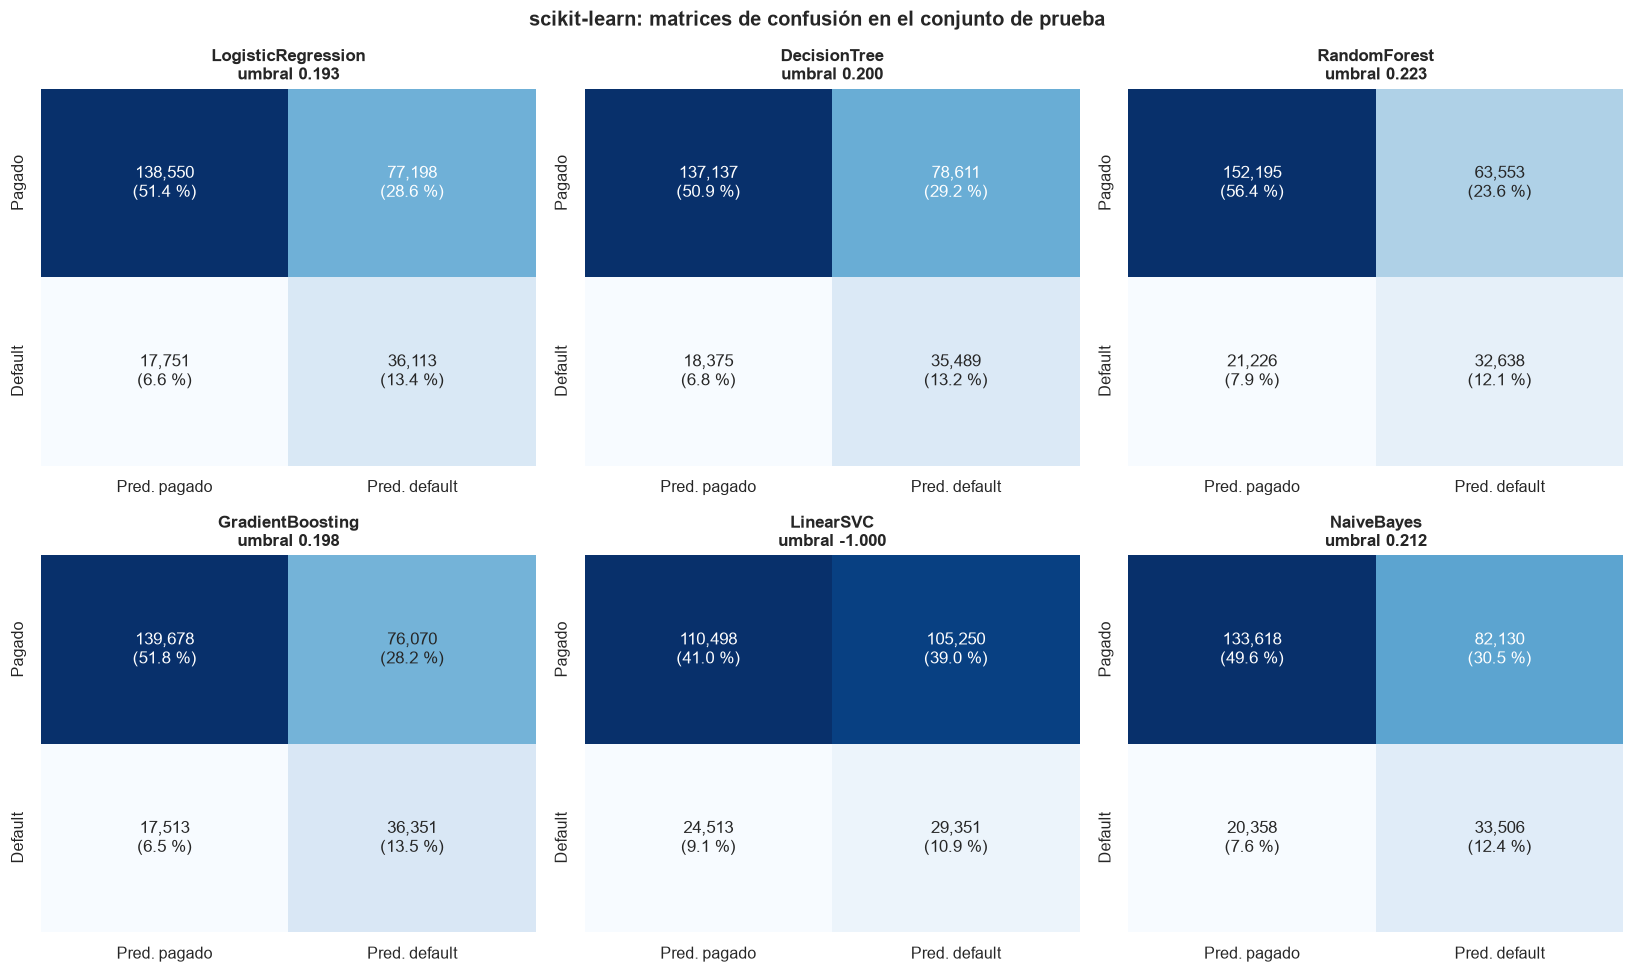

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m in zip(axes.ravel(), mo.ORDEN):
    r = resultados[m]["metricas_youden"]
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    sns.heatmap(cm, annot=np.array([[f"{v:,}\n({100 * v / cm.sum():.1f} %)" for v in fila] for fila in cm]),
                fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred. pagado", "Pred. default"], yticklabels=["Pagado", "Default"])
    ax.set_title(f"{m}\numbral {resultados[m]['umbral_youden']:.3f}")
fig.suptitle("scikit-learn: matrices de confusión en el conjunto de prueba", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "06_confusion_sklearn")
plt.show()

### Tiempos

In [13]:
tiempos = pd.DataFrame({m: {"validación cruzada (s)": resultados[m]["t_cv_s"],
                            "reajuste final (s)": resultados[m]["t_reajuste_s"],
                            "entrenamiento + CV (s)": resultados[m]["t_entrenamiento_cv_s"],
                            "predicción (s)": resultados[m]["t_prediccion_s"],
                            "ajustes": resultados[m]["n_ajustes"]} for m in mo.ORDEN}).T
tiempos.loc["Total"] = tiempos.sum()
print("Iteraciones del modelo final (límite):",
      {m: (resultados[m]["iteraciones"], resultados[m]["max_iter"]) for m in mo.ORDEN
       if resultados[m]["iteraciones"] is not None})
print(f"Preprocesamiento: {t_preproc:.1f} s")
tiempos.round(2)

Iteraciones del modelo final (límite): {'LogisticRegression': (35, 1000), 'LinearSVC': (97, 5000)}
Preprocesamiento: 17.6 s


,validación cruzada (s),reajuste final (s),entrenamiento + CV (s),predicción (s),ajustes
LogisticRegression,7.52,1.03,8.55,0.02,10.0
DecisionTree,13.26,6.75,20.00,0.04,10.0
RandomForest,191.66,23.60,215.26,0.39,28.0
GradientBoosting,703.44,401.45,1104.89,0.34,13.0
LinearSVC,600.79,15.37,616.15,0.02,10.0
NaiveBayes,1.61,0.32,1.93,0.09,4.0
Total,1518.28,448.52,1966.80,0.91,75.0


El entrenamiento completo con validación cruzada de los seis modelos tomó 1.967 s (33 min). El
gradient boosting concentra el 56 % del tiempo y el SVM lineal, por su convergencia lenta, otro
31 %; la regresión logística, el árbol y Naive Bayes se resuelven en segundos. La predicción de
las 269.612 observaciones de prueba tarda menos de medio segundo en todos los casos.